In [75]:
#work dir
setwd("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/")

In [97]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(lme4)
  library(broom.mixed)
  library(ggplot2)
library(dplyr)
library(tidyr)
library(tibble)
#library(ggridges)
    library(stringr)
library(tidyverse)
library(lmerTest)
library(broom.mixed)
library(ComplexHeatmap)
library(circlize)

})


In [98]:
##LOAD DATA######
all_df_aug <- read.table("/home/mjehangir/telomere-sv-analysis/data/all_df_aug_final_2026.txt",
                          sep = "\t",
                           header = TRUE)
head(all_df_aug)
colnames(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_rate_DUP_log,sv_rate_INS_log,sv_rate_INV_log,cnv_rate_per_mb_Loss_log,cnv_rate_per_mb_Gain_log,sv_proportion_BND_log,sv_proportion_DEL_log,arm_size_mb,HAR_rate_per_Mb,HAR_Distribution
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,-1.710542,-1.448588,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-3.671910,124.3391,0.00804246,1
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,-2.474780,-1.942610,-2.47478,-1.710542,-2.474780,-6.7196807,-4.094308,NA,NA,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-1.943328,-6.7196807,-5.330008,124.3391,0.00000000,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-1.710542,-2.47478,-2.474780,-2.474780,-6.7196807,-6.638746,NA,NA,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,-2.474780,-2.474780,-2.47478,-2.474780,-2.474780,-0.2645872,-6.638746,NA,NA,0


[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"

In [99]:
sv_counts <- read.table("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/aysa_severus_somatic_sv_summary_rate_prop_pq.tsv",
                           sep = "\t",
                           header = TRUE)
head(sv_counts)

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,region
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,chr1p
2,2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,chr1p
3,2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,chr1p
4,2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,chr1q
5,2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,chr1q
6,2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,chr10p


In [100]:

# 1. Pivot using quotes to distinguish column names from the dataframe object
sv_pivoted <- sv_counts %>%
  pivot_wider(
    id_cols = c(filename, region), 
    names_from = type, 
    values_from = c("sv_count", "sv_size_sum"), # Added quotes here
    names_sep = "_"
  )

# 2. Merge into the main dataframe
all_df_aug <- all_df_aug %>%
  left_join(sv_pivoted, by = c("Sample_ID" = "filename", "chr_arm" = "region"))

# Check the result
head(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_count_BND,sv_count_DUP,sv_count_INS,sv_count_DEL,sv_count_INV,sv_size_sum_BND,sv_size_sum_DUP,sv_size_sum_INS,sv_size_sum_DEL,sv_size_sum_INV
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,1,2,4,NA,NA,0.00000,0.032036,0,NA,NA
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,2,NA,NA,1,NA,0.00000,NA,NA,0.026438,NA
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,48,NA,1,4,NA,0.00000,NA,0,0.009955,NA
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,39,NA,NA,1,NA,0.00000,NA,NA,0.000553,NA
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,41,NA,2,NA,NA,0.00000,NA,0,NA,NA
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,61,NA,NA,NA,NA,67.61145,NA,NA,NA,NA


In [101]:

all_df_aug <- all_df_aug %>%
  mutate(across(starts_with("sv_count"), ~replace_na(., 0)),
         across(starts_with("sv_size_sum"), ~replace_na(., 0)))

# Check the first few rows to confirm the NAs are gone
head(all_df_aug)
colnames(all_df_aug)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_count_BND,sv_count_DUP,sv_count_INS,sv_count_DEL,sv_count_INV,sv_size_sum_BND,sv_size_sum_DUP,sv_size_sum_INS,sv_size_sum_DEL,sv_size_sum_INV
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,1,2,4,0,0,0.00000,0.032036,0,0.000000,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,2,0,0,1,0,0.00000,0.000000,0,0.026438,0
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,48,0,1,4,0,0.00000,0.000000,0,0.009955,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,39,0,0,1,0,0.00000,0.000000,0,0.000553,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,41,0,2,0,0,0.00000,0.000000,0,0.000000,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,61,0,0,0,0,67.61145,0.000000,0,0.000000,0


[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"          
[41] "sv_count_BND"               "sv_count_DUP"              
[43] "sv_count_INS"               "sv_count_DEL"              
[45] "sv_count_INV"               "sv_size_sum_BND"           
[47] "sv_size_sum_DUP"            "sv_size_sum_INS"           
[49] "sv_size_sum_DEL"            "sv_size_sum_INV"

In [102]:
BNDs_manual <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/complex_BNDs_manual_annotation.csv",
                           sep = ",",
                           header = TRUE)
BNDs_software <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/complex_BNDs_counts_rate.csv",
                           sep = ",",
                           header = TRUE)
head(BNDs_manual)
head(BNDs_software)

,Sample,Arm_ID,THR,S_SV,FB,TIC,M_SV,PLX,Total_Hits
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,3188,chr14p,1,0,0,0,0,0,1
2,3188,chr14q,1,0,0,0,0,0,1
3,3188,chr5p,1,0,0,0,0,0,1
4,3188,chr5q,1,0,0,0,0,0,1
5,3188,chr13p,0,1,0,0,0,0,1
6,3188,chr13q,0,1,0,0,0,0,1


,Sample,Arm,Subtype,Count,Rate_per_Mb
,<chr>,<chr>,<chr>,<int>,<chr>
1,3188,chr14q,complex_inv,366,4.0775
2,3188,chr5p,complex_inv,166,3.4356
3,6365A,chr11q,complex_inv,266,3.2288
4,3188,chr5q,complex_inv,308,2.3032
5,6439C,chr12q,complex_inv,220,2.2584
6,6365A,chr15q,complex_inv,126,1.526


In [183]:
BNDs_software %>%
  # 1. Look for the value "6277A" inside the Sample column
  filter(Sample == "6277A") 
  head(BNDs_software )

Sample,Arm,Subtype,Count,Rate_per_Mb
<chr>,<chr>,<chr>,<int>,<chr>
6277A,chr13q,complex_inv,40,0.4122
6277A,chr18q,complex_inv,24,0.3865
6277A,chr2q,complex_inv,48,0.3217
6277A,chr13p,Templated_ins,4,0.2421
6277A,chr19q,reciprocal_inv_del,8,0.2359
6277A,chr10p,Templated_ins,8,0.1968
6277A,chr10p,inv_tra,8,0.1968
6277A,chr19q,Templated_ins,6,0.1769
6277A,chr14p,complex_inv,2,0.1754


,Sample,Arm,Subtype,Count,Rate_per_Mb
,<chr>,<chr>,<chr>,<int>,<chr>
1,3188,chr14q,complex_inv,366,4.0775
2,3188,chr5p,complex_inv,166,3.4356
3,6365A,chr11q,complex_inv,266,3.2288
4,3188,chr5q,complex_inv,308,2.3032
5,6439C,chr12q,complex_inv,220,2.2584
6,6365A,chr15q,complex_inv,126,1.526


In [108]:

# Standardize column names for joining
BNDs_manual_clean <- BNDs_manual %>%
  rename(Sample_ID = Sample, chr_arm = Arm_ID)

# Join manual annotations to the augmented dataframe
all_df_integrated <- all_df_aug %>%
  left_join(BNDs_manual_clean, by = c("Sample_ID", "chr_arm")) %>%
  # Replace NAs with 0 for arms that had no manual complex events
  mutate(across(c(THR, S_SV, FB, TIC, M_SV, PLX, Total_Hits), ~replace_na(., 0)))
head(all_df_integrated)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,sv_size_sum_INS,sv_size_sum_DEL,sv_size_sum_INV,THR,S_SV,FB,TIC,M_SV,PLX,Total_Hits
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0.000000,0,0,0,0,0,0,0,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,0.026438,0,0,0,0,0,0,0,0
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,0.009955,0,0,0,0,0,0,0,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,0.000553,0,0,0,0,0,0,0,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0.000000,0,0,1,0,0,0,0,1
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0.000000,0,0,1,0,0,0,0,1


In [110]:

# 1. Clean and convert types in the software data
BNDs_software_numeric <- BNDs_software %>%
  rename(Sample_ID = Sample, chr_arm = Arm) %>%
  mutate(
    # Ensure Count and Rate are numeric so pivot_wider can use 0 for fill
    Count = as.numeric(as.character(Count)),
    Rate_per_Mb = as.numeric(as.character(Rate_per_Mb))
  ) %>%
  select(Sample_ID, chr_arm, Subtype, Count, Rate_per_Mb)

# 2. Pivot to wide format
BNDs_software_wide <- BNDs_software_numeric %>%
  pivot_wider(
    names_from = Subtype, 
    values_from = c(Count, Rate_per_Mb), 
    names_glue = "auto_{Subtype}_{.value}",
    values_fill = 0  # Now this works because everything is numeric
  )

# 3. Final Integration Join
all_df_integrated <- all_df_aug %>%
  # Join Manual Annotations
  left_join(BNDs_manual %>% rename(Sample_ID = Sample, chr_arm = Arm_ID), 
            by = c("Sample_ID", "chr_arm")) %>%
  # Join Software Annotations
  left_join(BNDs_software_wide, by = c("Sample_ID", "chr_arm")) %>%
  # Clean up all NAs to 0 in one go
  mutate(across(c(THR, S_SV, FB, TIC, M_SV, PLX, Total_Hits), ~replace_na(., 0)),
         across(starts_with("auto_"), ~replace_na(., 0)))



In [112]:

head(all_df_integrated)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_foldback_Count,auto_inv_tra_Count,auto_Templated_ins_inv_Count,auto_complex_inv_Rate_per_Mb,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0,0,0.0000,0,0,0,0,0,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0.0965,0,0,0,0,0,0


In [179]:
all_df_integrated %>%
  # 1. Look for the value "6277A" inside the Sample column
  filter(Sample_ID == "6277A")
  head(all_df_integrated)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_foldback_Count,auto_inv_tra_Count,auto_Templated_ins_inv_Count,auto_complex_inv_Rate_per_Mb,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6277A,chr1p,5.311000,0.408155233,0.000000000,0.008061378,0.00000000,0.150054849,0.000000000,0.008061378,⋯,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
6277A,chr1q,4.704750,0.360432164,0.008042525,0.008042525,0.17706914,0.038633274,0.024127575,0.000000000,⋯,0,4,0,0.0322,0.0322,0.0000,0.0000,0.0000,0.0322,0
6277A,chr2p,4.544250,0.347797851,0.010694812,0.010694812,0.17974472,0.002139829,0.000000000,0.000000000,⋯,0,2,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0214,0
6277A,chr2q,5.423500,0.417011060,0.020108119,0.000000000,0.25346247,0.000000000,0.013405413,0.020108119,⋯,0,0,0,0.3217,0.0000,0.0536,0.0000,0.0000,0.0000,0
6277A,chr3p,5.097900,0.391380328,0.063777873,0.000000000,0.69129291,0.000000000,0.010629646,0.000000000,⋯,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
6277A,chr3q,6.069000,0.467823828,0.000000000,0.028029673,0.00000000,0.712327489,0.009343224,0.000000000,⋯,0,0,0,0.0187,0.0000,0.0000,0.0000,0.0000,0.0000,0
6277A,chr4p,4.112500,0.313811154,0.000000000,0.000000000,0.00000000,0.000000000,0.057194633,0.000000000,⋯,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
6277A,chr4q,4.390500,0.335694887,0.014172087,0.000000000,0.04397322,0.000000000,0.000000000,0.000000000,⋯,0,0,0,0.0000,0.0000,0.0567,0.0000,0.0000,0.0000,0
6277A,chr5p,5.226833,0.401529762,0.000000000,0.020696273,0.00000000,0.103507255,0.000000000,0.000000000,⋯,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_foldback_Count,auto_inv_tra_Count,auto_Templated_ins_inv_Count,auto_complex_inv_Rate_per_Mb,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0,0,0.0000,0,0,0,0,0,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0.0000,0,0,0,0,0,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0.0965,0,0,0,0,0,0


In [156]:


# 1. Generate counts per arm, fixing the 'ample' column name
arm_type_counts <- ecdna_subtypes %>%
  # Rename the typo column to 'Sample_ID' to match your integrated df
  rename(Sample_ID = 1) %>% 
  group_by(Sample_ID, chr_arm, topology_name) %>%
  summarise(Type_Count = n(), .groups = "drop") %>%
  # Pivot to wide format so each topology is its own column
  pivot_wider(names_from = topology_name, values_from = Type_Count, values_fill = 0)

# 2. Join this back to your main integrated dataframe
all_df_final <- all_df_integrated %>%
  left_join(arm_type_counts, by = c("Sample_ID", "chr_arm")) %>%
  # Replace NAs with 0 for arms that didn't have specific ecDNA topologies
  mutate(across(everything(), ~replace_na(., 0)))

# Preview the final result
head(all_df_final)

,Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb,simple_circle,multi_region_intra_chr,simple_sv,multi_region_inter_chr
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
1,2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0,0,0,0,0,0,0,0,0
2,2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0,0,0,0,0,2,0
3,3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
4,3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,0,0,0,0,0,0,0,2,0
5,3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
6,3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
library(dplyr)

# Rename the specific columns to clarify they are ecDNA-derived
all_df_final <- all_df_final %>%
  rename(
    ecdna_simple_circle = simple_circle,
    ecdna_multi_region_intra_chr = multi_region_intra_chr,
    ecdna_simple_sv = simple_sv,
    ecdna_multi_region_inter_chr = multi_region_inter_chr
  )

# Verify the new column names
colnames(all_df_final)[tail(1:ncol(all_df_final), 10)]

In [165]:
colnames(all_df_final)

[1] "Sample_ID"                           "chr_arm"                            
 [3] "final_average_TL_p75_kb"             "norm_TL"                            
 [5] "cnv_rate_per_mb_Gain"                "cnv_rate_per_mb_Loss"               
 [7] "cnv_proportion_per_mb_Gain"          "cnv_proportion_per_mb_Loss"         
 [9] "sv_rate_DEL"                         "sv_rate_DUP"                        
[11] "sv_rate_BND"                         "sv_rate_INS"                        
[13] "sv_rate_INV"                         "sv_proportion_DEL"                  
[15] "sv_proportion_DUP"                   "sv_proportion_BND"                  
[17] "sv_proportion_INS"                   "sv_proportion_INV"                  
[19] "aneuploidy"                          "TL_zscore"                          
[21] "aneu_loss"                           "aneu_gain"                          
[23] "ecDNA_estprop_sum"                   "HAR_ecDNA_count"                    
[25] "Age"                                 "has_ecdna"                          
[27] "ecdna_max_amp"                       "num_circuits"                       
[29] "sv_rate_BND_log"                     "sv_rate_DEL_log"                    
[31] "sv_rate_DUP_log"                     "sv_rate_INS_log"                    
[33] "sv_rate_INV_log"                     "cnv_rate_per_mb_Loss_log"           
[35] "cnv_rate_per_mb_Gain_log"            "sv_proportion_BND_log"              
[37] "sv_proportion_DEL_log"               "arm_size_mb"                        
[39] "HAR_rate_per_Mb"                     "HAR_Distribution"                   
[41] "sv_count_BND"                        "sv_count_DUP"                       
[43] "sv_count_INS"                        "sv_count_DEL"                       
[45] "sv_count_INV"                        "sv_size_sum_BND"                    
[47] "sv_size_sum_DUP"                     "sv_size_sum_INS"                    
[49] "sv_size_sum_DEL"                     "sv_size_sum_INV"                    
[51] "Chromothripsis"                      "Single_Chr_Complex_Rearrangement"   
[53] "Foldback_Translocation"              "Templated_Insertion_Chains"         
[55] "Multiple_Chr_Complex_Rearrangement"  "Chromoplexy"                        
[57] "Total_Complex_SV_Hits"               "auto_complex_inv_Count"             
[59] "auto_Templated_ins_Count"            "auto_dup_inv_segment_Count"         
[61] "auto_reciprocal_inv_del_Count"       "auto_foldback_Count"                
[63] "auto_inv_tra_Count"                  "auto_Templated_ins_inv_Count"       
[65] "auto_complex_inv_Rate_per_Mb"        "auto_Templated_ins_Rate_per_Mb"     
[67] "auto_dup_inv_segment_Rate_per_Mb"    "auto_reciprocal_inv_del_Rate_per_Mb"
[69] "auto_foldback_Rate_per_Mb"           "auto_inv_tra_Rate_per_Mb"           
[71] "auto_Templated_ins_inv_Rate_per_Mb"  "ecdna_simple_circle"                
[73] "ecdna_multi_region_intra_chr"        "ecdna_simple_sv"                    
[75] "ecdna_multi_region_inter_chr"

In [114]:

all_df_integrated <- all_df_integrated %>%
  rename(
    Chromothripsis = THR,
    Single_Chr_Complex_Rearrangement = S_SV,
    Foldback_Translocation = FB,
    Templated_Insertion_Chains = TIC,
    Multiple_Chr_Complex_Rearrangement = M_SV,
    Chromoplexy = PLX,
    Total_Complex_SV_Hits = Total_Hits
  )


[1] "Chromothripsis"                     "Single_Chr_Complex_Rearrangement"  
[3] "Foldback_Translocation"             "Templated_Insertion_Chains"        
[5] "Multiple_Chr_Complex_Rearrangement" "Chromoplexy"                       
[7] "Total_Complex_SV_Hits"

In [154]:
ecdna_subtypes <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/ecDNA_subtypes_tel.csv",
                           sep = ",",
                           header = TRUE)
head(ecdna_subtypes)

,sample,Chromosome,Arm,chr_arm,start,end,TL_kb,norm_TL,ArmLen,estimated_proportions,fragment_id,circ_id,topology_name,label
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,2436A,chr1,q,chr1q,196089010,196200712,5.05116666666667,-0.213403008262126,124339061,108,989.993,1,simple_sv,ecDNA
2,2436A,chr1,q,chr1q,196202843,196213045,5.05116666666667,-0.213403008262126,124339061,108,1001,1,simple_sv,ecDNA
3,2436A,chr14,q,chr14q,100384316,100903138,3.4906,-1.53582374126121,89761231,72,12905,25,simple_circle,ecDNA
4,2436A,chr6,q,chr6q,132892661,132908593,5.89692857142857,0.50329375447658,112454080,58,6365,18,multi_region_inter_chr,ecDNA
5,2436A,chr7,q,chr7q,145478082,145544265,6.48308333333333,1,98502993,58,7405.7413.7417,18,multi_region_inter_chr,ecDNA
6,2436A,chr7,q,chr7q,145467433,145478082,6.48308333333333,1,98502993,58,7401,18,multi_region_inter_chr,ecDNA


In [166]:
write.table(all_df_final, 
            file = "/home/mjehangir/telomere-sv-analysis/data/all_df_aug_final_18_03_2026.txt", 
            sep = "\t", 
            row.names = FALSE, 
            quote = FALSE)

In [128]:
all_df_aug <- all_df_integrated %>%
  group_by(Sample_ID) %>%
  mutate(
    zscore_sample_wise_tel = (final_average_TL_p75_kb - mean(final_average_TL_p75_kb, na.rm = TRUE)) / 
                              sd(final_average_TL_p75_kb, na.rm = TRUE)
  ) %>%
  ungroup()
head(all_df_aug)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_inv_tra_Count,auto_Templated_ins_inv_Count,auto_complex_inv_Rate_per_Mb,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb,zscore_sample_wise_tel
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr1p,5.221000,0.4010706,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.01612276,⋯,0,0,0.0000,0,0,0,0,0,0,-0.1769929
2436A,chr1q,5.051167,0.3877016,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,⋯,0,0,0.0000,0,0,0,0,0,0,-0.2722204
3188,chr1p,1.642500,0.1193765,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,⋯,0,0,0.0000,0,0,0,0,0,0,-1.9215054
3188,chr1q,3.086500,0.2330460,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,⋯,0,0,0.0000,0,0,0,0,0,0,0.4947718
3988,chr1p,2.347500,0.1748731,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0.0000,0,0,0,0,0,0,-1.6673439
3988,chr1q,5.083000,0.3902074,0.000000000,0.00000000,0.000000000,0.0000000,0.000000000,0.00000000,⋯,0,0,0.0965,0,0,0,0,0,0,-0.2781350


In [129]:

# --- 1. SET UP VARIABLES ---
# List of genomic instability metrics to correlate against Telomere Length (norm_TL)
target_vars <- c("sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INV", "sv_rate_INS",
                 "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", "HAR_ecDNA_count","HAR_rate_per_Mb","HAR_Distribution", "aneu_loss", "aneu_gain", "ecDNA_estprop_sum", "has_ecdna","ecdna_max_amp","num_circuits")

# --- 2. CALCULATE CORRELATIONS ---
# Perform Spearman Correlation for each variable against Normalized Telomere Length.
# Spearman is used here to capture non-linear, monotonic relationships.
res_forest_all <- lapply(target_vars, function(v) {
  if(v %in% colnames(all_df_aug)) {
    # Conduct test; exact=FALSE prevents errors with tied ranks in large datasets
    cor_test <- cor.test(all_df_aug$zscore_sample_wise_tel, all_df_aug[[v]], method = "spearman", exact = FALSE)
    
    data.frame(
      Feature = v,
      Rho = cor_test$estimate,
      Pval = cor_test$p.value
    )
  }
}) %>% bind_rows()

# --- 3. DATA CLEANING & CATEGORIZATION FOR PLOTTING ---
# Prepare the results by renaming variables and assigning significance levels.
plot_data <- res_forest_all %>%
  mutate(
    # Human-readable labels for the Y-axis
    Feature_Clean = case_when(
      Feature == "sv_rate_BND"        ~ "Translocation (BND)",
      Feature == "sv_rate_DEL"        ~ "Deletions (DEL)",
      Feature == "sv_rate_DUP"        ~ "Duplication (DUP)",
      Feature == "sv_rate_INV"        ~ "Inversion (INV)",
      Feature == "sv_rate_INS"        ~ "Insertion (INS)",
      Feature == "cnv_rate_per_mb_Loss" ~ "Large-scale Loss",
      Feature == "cnv_rate_per_mb_Gain" ~ "Large-scale Gain",
      Feature == "HAR_ecDNA_count"    ~ "HARs (ecDNA)",
      Feature == "aneuploidy"         ~ "Aneuploidy",
      Feature == "HAR_Distribution"         ~ "HAR_Distribution",
              Feature == "HAR_rate_per_Mb"         ~ "HAR_rate_per_Mb",


      TRUE ~ Feature
    ),
    
    # Group variables by biological category for easier visualization/coloring
    Bio_Group = case_when(
      grepl("HAR|ecDNA", Feature) ~ "Extrachromosomal (HARs)",
      grepl("sv", Feature)        ~ "Structural Variation (SV)",
      TRUE                        ~ "Copy Number Variation (CNV)"
    ),
    
    # Standardize p-value significance markers
    Signif_Label = case_when(
      Pval < 0.001 ~ "***",
      Pval < 0.01  ~ "**",
      Pval < 0.05  ~ "*",
      TRUE         ~ "n.s."
    )
  ) %>%
  # Sort by Rho value so the resulting plot shows a clear trend (e.g., Forest Plot)
  arrange(Rho) %>%
  mutate(Feature_Clean = factor(Feature_Clean, levels = unique(Feature_Clean)))

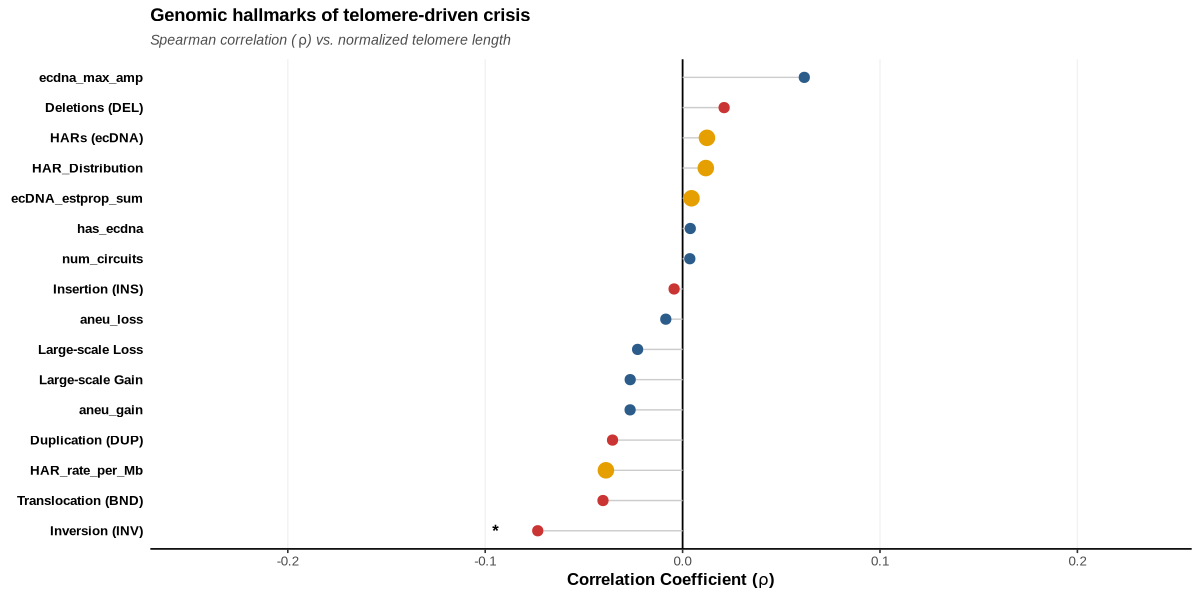

In [130]:
# --- 1. PREPARE PLOT AESTHETICS ---
plot_data <- plot_data %>%
  mutate(
    # Ensure Signif_Label matches your previous step's "n.s." string
    Clean_Signif = ifelse(Signif_Label == "n.s.", "", Signif_Label),
    
    # Assign Nature-inspired hex codes based on biological groups
    Final_Color = case_when(
      Bio_Group == "Extrachromosomal (HARs)" ~ "#E69F00", # Gold
      Bio_Group == "Structural Variation (SV)" ~ "#CA3433", # Red
      TRUE                                     ~ "#2B5C8A"  # Steel Blue (CNVs)
    ),
    
    # Visual emphasis: larger points for HARs/ecDNA
    Point_Size = ifelse(Bio_Group == "Extrachromosomal (HARs)", 4, 2.5)
  ) %>%
  # Re-confirming factor levels based on Rho for the forest plot gradient
  arrange(Rho) %>% 
  mutate(Feature_Clean = factor(Feature_Clean, levels = unique(Feature_Clean)))

# --- 2. GENERATE FOREST PLOT ---
ggplot(plot_data, aes(x = Rho, y = Feature_Clean)) +
  # Reference line at zero
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  
  # Lollipop segments: connecting the y-axis to the data point
  geom_segment(aes(x = 0, xend = Rho, yend = Feature_Clean),
               color = "grey80", linewidth = 0.4) +
  
  # Data points with dynamic color and size
  geom_point(aes(color = Final_Color, size = Point_Size)) +
  
  # Dynamic Significance Labels: Positioned based on Rho direction (+ or -)
  geom_text(aes(label = Clean_Signif, 
                x = Rho + ifelse(Rho < 0, -0.02, 0.02),
                hjust = ifelse(Rho < 0, 1, 0)), 
            size = 3.5, fontface = "bold") +
  
  # Use Identity scales to apply the hex codes and sizes defined in mutate()
  scale_color_identity() +
  scale_size_identity() +
  scale_x_continuous(expand = c(0.15, 0.15)) + 
  
  # Professional Labels using plotmath for symbols
  labs(
    title = "Genomic hallmarks of telomere-driven crisis",
    subtitle = expression(italic("Spearman correlation (") * rho * italic(") vs. normalized telomere length")),
    x = expression(bold("Correlation Coefficient (") * rho * bold(")")),
    y = NULL
  ) +
  
  # Minimalist Science Theme
  theme_classic(base_size = 10) +
  theme(
    axis.line.y  = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.y  = element_text(face = "bold", color = "black"),
    plot.title   = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 8.5, color = "grey30"),
    panel.grid.major.x = element_line(color = "grey95", linewidth = 0.4)
  )

In [132]:

# --- 1. BIN TELOMERE LENGTHS INTO QUINTILES ---
# Discretize continuous telomere length into 5 equal-sized groups 
# Note: ntile(1) = Shortest/Crisis, ntile(5) = Longest
all_df_aug <- all_df_aug %>%
  mutate(
   TL_Group = ntile(zscore_sample_wise_tel, 5),
   TL_Group = factor(TL_Group, 
                      levels = 1:5, 
                      labels = c("Very Short", "Short", "Intermediate", "Long", "Very Long"))
    #  TL_Group = ntile(zscore_sample_wise_tel, 3),
   # TL_Group = factor(TL_Group, 
         #            levels = 1:3, 
               #       labels = c("Short", "Intermediate", "Long"))
  )

# --- 2. CALCULATE MEAN INTENSITY PER GROUP ---
# Aggregate instability metrics to see the "Broad Peak" shifts across TL groups
target_vars <- c(
  # --- Original Genomic Rates (Log Transformed) ---
  "sv_rate_BND_log", "sv_rate_DEL_log", "sv_rate_DUP_log", 
  "sv_rate_INS_log", "sv_rate_INV_log", "cnv_rate_per_mb_Loss_log",
  "cnv_rate_per_mb_Gain_log", 
  
  # --- Manual Complex SV Annotations (Renamed) ---
  "Chromothripsis", 
  "Templated_Insertion_Chains", 
  "Foldback_Translocation", 
  "Single_Chr_Complex_Rearrangement", 
  "Multiple_Chr_Complex_Rearrangement",
  "Chromoplexy",
  "Total_Complex_SV_Hits",
  
  # --- ecDNA / HAR Metrics ---
  "HAR_ecDNA_count", 
  "HAR_Distribution", 
  "HAR_rate_per_Mb", 
  "ecDNA_estprop_sum",
  #"ecDNA_Present",   # Binary flag
  #"ecDNA_Size_Mb",   # Genomic footprint
  
  # --- Aneuploidy ---
  "aneu_loss", "aneu_gain",
  
  # --- Software Automated Complex Metrics ---
  "auto_complex_inv_Count",
  "auto_complex_inv_Rate_per_Mb"
)

heatmap_df <- all_df_aug %>%
  group_by(TL_Group) %>%
  # Use an anonymous function to calculate means while ignoring NA values
  summarise(across(all_of(target_vars), ~mean(.x, na.rm = TRUE)), .groups = "drop") %>%
  # Reshape for matrix transformation; clean variable names for the final plot
  pivot_longer(-TL_Group, names_to = "Variable", values_to = "Mean_Val") %>%
  mutate(Variable = gsub("_log", "", Variable))

# --- 3. TRANSFORM TO SCALED MATRIX FOR HEATMAP ---
# Convert to a matrix format and apply Z-score scaling by row (Variable-wise)
# This highlights the relative change of each feature across TL groups.
heatmap_mat <- heatmap_df %>%
  pivot_wider(names_from = TL_Group, values_from = Mean_Val) %>%
  tibble::column_to_rownames("Variable") %>%
  as.matrix()


In [133]:
head(all_df_aug, 2)
unique(all_df_aug$TL_Group)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,⋯,auto_Templated_ins_inv_Count,auto_complex_inv_Rate_per_Mb,auto_Templated_ins_Rate_per_Mb,auto_dup_inv_segment_Rate_per_Mb,auto_reciprocal_inv_del_Rate_per_Mb,auto_foldback_Rate_per_Mb,auto_inv_tra_Rate_per_Mb,auto_Templated_ins_inv_Rate_per_Mb,zscore_sample_wise_tel,TL_Group
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
2436A,chr1p,5.221000,0.4010706,0.000000000,0,0.000000000,0,0.000000000,0.01612276,⋯,0,0,0,0,0,0,0,0,-0.1769929,Intermediate
2436A,chr1q,5.051167,0.3877016,0.008042525,0,0.001609727,0,0.008042525,0.00000000,⋯,0,0,0,0,0,0,0,0,-0.2722204,Intermediate


[1] Intermediate Very Short   Long         Short        Very Long   
Levels: Very Short Short Intermediate Long Very Long

In [134]:
# 1. Calculate One-Way ANOVA P-values for each row
sig_labels <- sapply(target_vars, function(v) {
    
    # This anova test compare if there the mean is different across the 5 groups
    fit <- aov(all_df_aug[[v]] ~ all_df_aug$TL_Group)
    # Extract the p-value from the summary
    p <- summary(fit)[[1]][["Pr(>F)"]][1]
    
    # Handle NAs or empty values
    if(is.na(p)) return("")
    
    # Return Significance Stars
    if(p < 0.001) return("***")
    else if(p < 0.01) return("**")
    else if(p < 0.05) return("*")
    else return("")
})

# 2. Place stars in the star_matrix
star_matrix <- matrix("", nrow = nrow(heatmap_mat), ncol = ncol(heatmap_mat))
star_matrix[, 5] <- sig_labels # Placing stars position

In [135]:
# # Scale values for heatmap
heatmap_scaled <- t(apply(heatmap_mat, 1, scale))
colnames(heatmap_scaled) <- colnames(heatmap_mat)
# Clean feature names: Replace underscores with spaces for publication-ready labels
rownames(heatmap_scaled) <- gsub("_", " ", rownames(heatmap_mat))

In [136]:
head(heatmap_scaled)

,Very Short,Short,Intermediate,Long,Very Long
sv rate BND,1.4875846,-0.88425869,0.55856961,-0.6762838,-0.4856117
sv rate DEL,0.3435836,-1.53842507,0.96921418,-0.4117665,0.6373938
sv rate DUP,0.8456943,-0.04596783,1.08872909,-1.3406018,-0.5478538
sv rate INS,1.0162060,-1.15640666,0.58809102,-0.9933264,0.5454361
sv rate INV,0.5545072,1.47559504,-0.36970514,-0.8301985,-0.8301985
cnv rate per mb Loss,1.4003067,-0.76359553,-0.05977561,-1.0903601,0.5134245


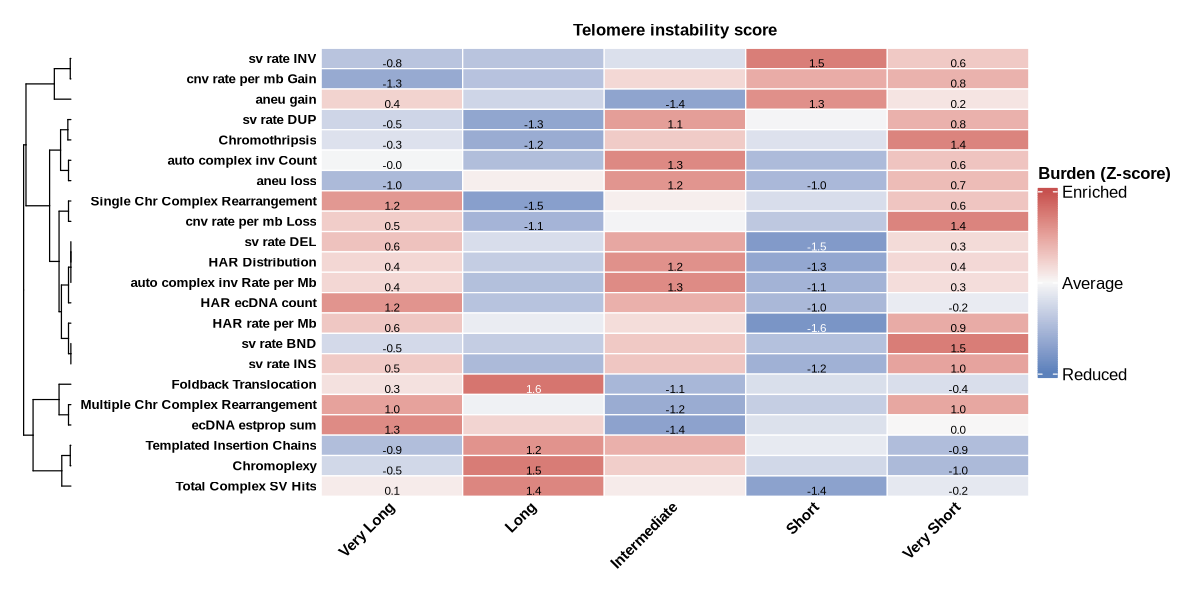

In [138]:
# --- 2. COLOR & THEME CONFIGURATION ---
# Diverging palette: Blue (Low/Stable) -> White (Average) -> Red (High/Crisis)

# Thresholds at +/- 2.5 prevent extreme outliers from compressing the mid-range colors.
col_fun <- colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "#F7F7F7", "#B2182B"))

# --- 3. HEATMAP CONSTRUCTION ---
h_plot <- Heatmap(heatmap_scaled, 
        name = "Z-score", 
        col = col_fun,
        
        # COLUMN LOGIC: Fixed Biological Gradient (Longest to Shortest)
        cluster_columns = FALSE, 
        column_order    = c("Very Long", "Long", "Intermediate", "Short", "Very Short"),
        #        column_order    = c( "Long", "Intermediate", "Short"),

        # ROW LOGIC: Cluster features by similar response patterns
        cluster_rows             = TRUE,
        clustering_distance_rows = "spearman", 
        
        # GRID AESTHETICS
        rect_gp      = gpar(col = "white", lwd = 1), # White borders for "tile" look
        column_title = "Telomere instability score",
        column_title_gp = gpar(fontsize = 10, fontface = "bold"),
        
        # DYNAMIC CELL LABELING
        cell_fun = function(j, i, x, y, width, height, fill) {
            val <- heatmap_scaled[i, j]
            
            # A. Overlay Significance Stars (assumes star_matrix exists)
            if(exists("star_matrix") && star_matrix[i, j] != "") {
                grid.text(star_matrix[i, j], x, y + unit(2, "mm"), 
                          gp = gpar(fontsize = 10, fontface = "bold"))
            }
            
            # B. Selective Text: Only label "Extreme" values or "Anchor" cohorts
            is_extreme <- abs(val) > 1.0
            is_anchor  <- colnames(heatmap_scaled)[j] %in% c("Very Short", "Very Long")
            
            if(is_extreme | is_anchor) {
                grid.text(sprintf("%.1f", val), x, y - unit(1, "mm"), 
                          gp = gpar(fontsize = 7, 
                                    # Adaptive text color for contrast against dark tiles
                                    col = ifelse(abs(val) > 1.5, "white", "black")))
            }
        },
        
        # heamtmap LEGEND
        row_names_side   = "left",
        row_names_gp     = gpar(fontsize = 8, fontface = "bold"),
        column_names_gp  = gpar(fontsize = 9, fontface = "bold"),
        column_names_rot = 45,
        
        heatmap_legend_param = list(
            title = "Burden (Z-score)",
            at = c(-2, 0, 2),
            labels = c("Reduced", "Average", "Enriched"),
            legend_height = unit(4, "cm"),
            title_position = "topleft"
        )
)

# --- 4. heatmap plot ---
# Set plotting dimensions for Jupyter/RStudio
options(repr.plot.width = 10, repr.plot.height = 5)

draw(h_plot, 
     heatmap_legend_side = "right", 
     padding = unit(c(5, 5, 5, 5), "mm"))

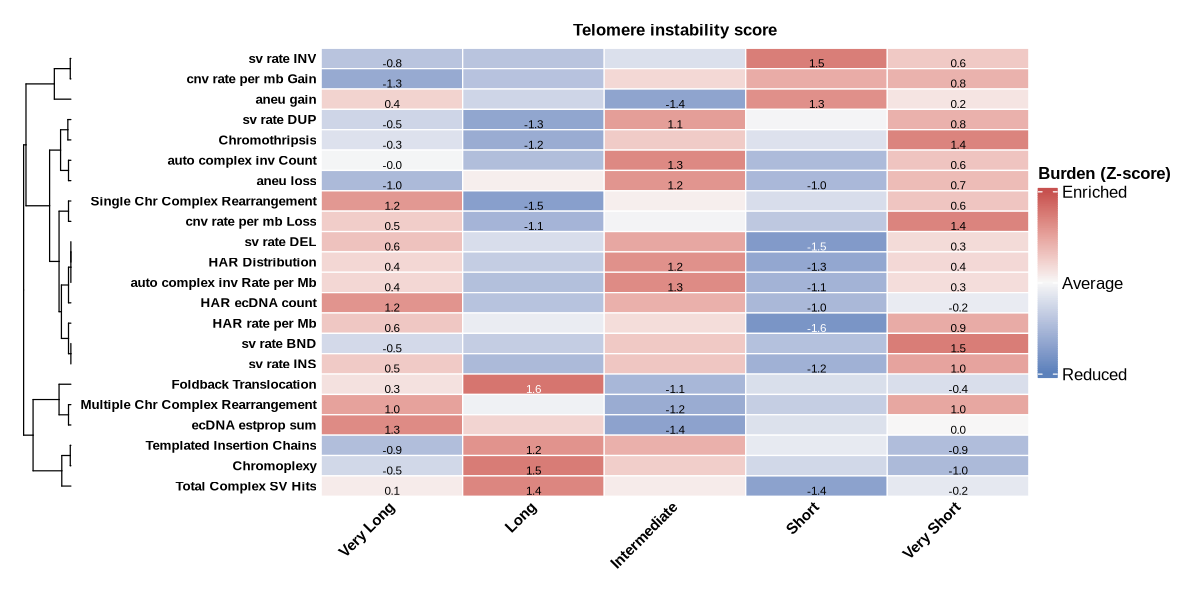

In [139]:
#pdf(
  #file = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_heatmap.pdf",
 # width = 10,
 # height = 4,
 # useDingbats = FALSE
#)

draw(
  h_plot,
  heatmap_legend_side = "right",
  padding = unit(c(5, 5, 5, 5), "mm")
)

#dev.off()


In [22]:
colnames(all_df_aug)

[1] "Sample_ID"                  "chr_arm"                   
 [3] "final_average_TL_p75_kb"    "norm_TL"                   
 [5] "cnv_rate_per_mb_Gain"       "cnv_rate_per_mb_Loss"      
 [7] "cnv_proportion_per_mb_Gain" "cnv_proportion_per_mb_Loss"
 [9] "sv_rate_DEL"                "sv_rate_DUP"               
[11] "sv_rate_BND"                "sv_rate_INS"               
[13] "sv_rate_INV"                "sv_proportion_DEL"         
[15] "sv_proportion_DUP"          "sv_proportion_BND"         
[17] "sv_proportion_INS"          "sv_proportion_INV"         
[19] "aneuploidy"                 "TL_zscore"                 
[21] "aneu_loss"                  "aneu_gain"                 
[23] "ecDNA_estprop_sum"          "HAR_ecDNA_count"           
[25] "Age"                        "has_ecdna"                 
[27] "ecdna_max_amp"              "num_circuits"              
[29] "sv_rate_BND_log"            "sv_rate_DEL_log"           
[31] "sv_rate_DUP_log"            "sv_rate_INS_log"           
[33] "sv_rate_INV_log"            "cnv_rate_per_mb_Loss_log"  
[35] "cnv_rate_per_mb_Gain_log"   "sv_proportion_BND_log"     
[37] "sv_proportion_DEL_log"      "arm_size_mb"               
[39] "HAR_rate_per_Mb"            "HAR_Distribution"          
[41] "TL_Group"

In [78]:
# --- Save as PDF (vector, ideal for publication) ---
#ggsave(
  #filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_volcano.pdf",
 # plot = p,
 # width = 6,   # inches
  #height = 4,  # inches
  #units = "in",
  #device = "pdf"
#)

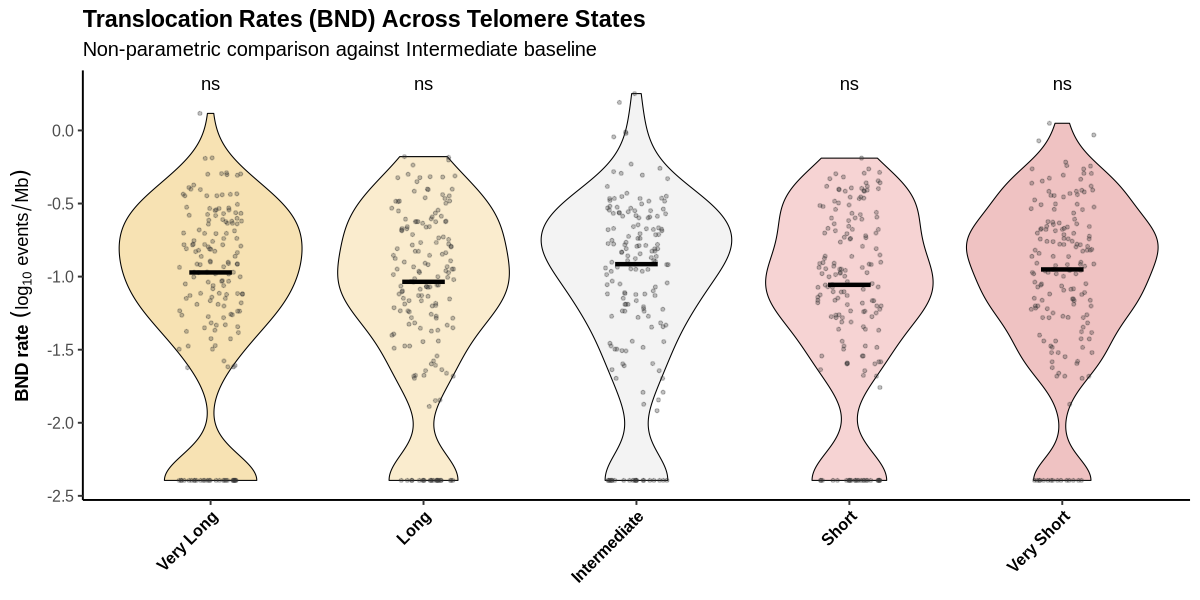

In [143]:
#For BNDs 

# --- 1. plot data prep ---
# Using mutate across to handle factor levels more cleanly
plot_simple <- all_df_aug %>%
  mutate(
    Q_val = ntile(zscore_sample_wise_tel, 5),
    Cohort = case_when(
      Q_val == 5 ~ "Very Long",
      Q_val == 4 ~ "Long",
      Q_val == 3 ~ "Intermediate",
      Q_val == 2 ~ "Short",
      Q_val == 1 ~ "Very Short"
    ),
    Cohort = factor(Cohort, levels = c("Very Long", "Long", "Intermediate", "Short", "Very Short"))
  )

# Define target variable once to avoid typos in multiple places
target_var <- "sv_rate_BND_log"

# --- 2. THE VIOLIN VISUAL WITH STATS ---
p <- ggplot(plot_simple, aes(x = Cohort, y = .data[[target_var]], fill = Cohort)) +
  # A. The Violin (Distribution Density)
  geom_violin(alpha = 0.3, color = "black", linewidth = 0.3, trim = TRUE) +
  
  # B. Individual Patients (Raw Data)
  geom_jitter(width = 0.15, alpha = 0.3, size = 0.8, color = "grey20") +
  
  # C. Central Tendency (Median)
  stat_summary(fun = median, geom = "crossbar", width = 0.2, color = "black") +
  
  # D. SIGNIFICANCE STARS (Non-parametric Wilcoxon)
  # Dynamically calculate label height to stay above the max data point
  stat_compare_means(
    ref.group = "Intermediate", 
    method = "wilcox.test",
    label = "p.signif", 
    hide.ns = FALSE, 
    label.y = max(plot_simple[[target_var]], na.rm = TRUE) * 1.1 
  ) +
  
  # E. Color Palette (Crisis Gradient)
  scale_fill_manual(values = c(
    "Very Long" = "#E69F00", "Long" = "#F0C15B", 
    "Intermediate" = "#D9D9D9", "Short" = "#E26D6D", "Very Short" = "#CA3433"
  )) +
  
  # F. Professional Labels
  labs(
    title = "Translocation Rates (BND) Across Telomere States",
    subtitle = "Non-parametric comparison against Intermediate baseline",
    x = NULL,
    y = expression(bold("BND rate") ~ (log[10] ~ events / Mb))
  ) +
  
  # G. Theme Refinement
  theme_classic(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(color = "black", face = "bold", angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", size = 14),
    axis.title.y = element_text(size = 11)
  )

print(p)

In [144]:
# --- Save as PDF (vector, ideal for publication) ---
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig3/new_sinaplot.pdf",
  plot = p,
  width = 8,   # inches
  height = 6,  # inches
  units = "in",
  device = "pdf"
)

In [151]:

# --- 1. INCLUDE ALL FEATURES (Manual, Auto, and Genomic Rates) ---
all_targets <- c(
  "sv_rate_BND", "sv_rate_DEL", "sv_rate_DUP", "sv_rate_INV", "sv_rate_INS",
  "cnv_rate_per_mb_Loss", "cnv_rate_per_mb_Gain", 
  "HAR_ecDNA_count", "HAR_rate_per_Mb", "ecDNA_estprop_sum",
  "aneu_gain", "aneu_loss",
  "Chromothripsis", "Templated_Insertion_Chains", "Foldback_Translocation", 
  "Total_Complex_SV_Hits"
)

# --- 2. EXECUTE MODELS (Linking features to Telomere Z-Score) ---
glm_all_results <- lapply(all_targets, function(v) {
  # Use all_df_integrated which has your renamed manual columns
  if(!(v %in% colnames(all_df_aug))) return(NULL)
  
  current_data <- all_df_aug %>% filter(!is.na(.data[[v]]), !is.na(zscore_sample_wise_tel))
  
  fit <- tryCatch({
    glm(as.formula(paste(v, "~ zscore_sample_wise_tel")), 
        data      = current_data, 
        family    = quasipoisson(link = "log"),
        na.action = na.exclude)
  }, error = function(e) return(NULL))

  if(is.null(fit)) return(NULL)

  s <- summary(fit)$coefficients
  if("zscore_sample_wise_tel" %in% rownames(s)) {
    data.frame(
      Variable = v,
      Estimate = s["zscore_sample_wise_tel", "Estimate"],
      StdErr   = s["zscore_sample_wise_tel", "Std. Error"],
      Pval     = s["zscore_sample_wise_tel", "Pr(>|t|)"]
    )
  }
}) %>% bind_rows()

# --- 3. DATA CLEANING, LABELING & RANKING ---
plot_data_all <- glm_all_results %>%
  mutate(
    # Create clean labels for the plot
    Label = Variable %>%
      gsub("sv_rate_", "SV: ", .) %>% 
      gsub("cnv_rate_per_mb_", "CNV: ", .) %>%
      gsub("HAR_ecDNA_count", "ecDNA Segment Count", .) %>%
      gsub("HAR_rate_per_Mb", "ecDNA Density", .) %>%
      gsub("Foldback_Translocation", "Foldback Transloc.", .) %>%
      gsub("Templated_Insertion_Chains", "TICs", .) %>%
      gsub("Total_Complex_SV_Hits", "Total Complex SVs", .) %>%
      gsub("aneu_", "Aneuploidy ", .) %>%
      gsub("_", " ", .),
    
    # Calculate Confidence Intervals
    Lower = Estimate - (1.96 * StdErr),
    Upper = Estimate + (1.96 * StdErr)
  ) %>%
  # Rank by Estimate so the plot is easy to read
  arrange(Estimate) %>%
  mutate(Label = factor(Label, levels = Label))


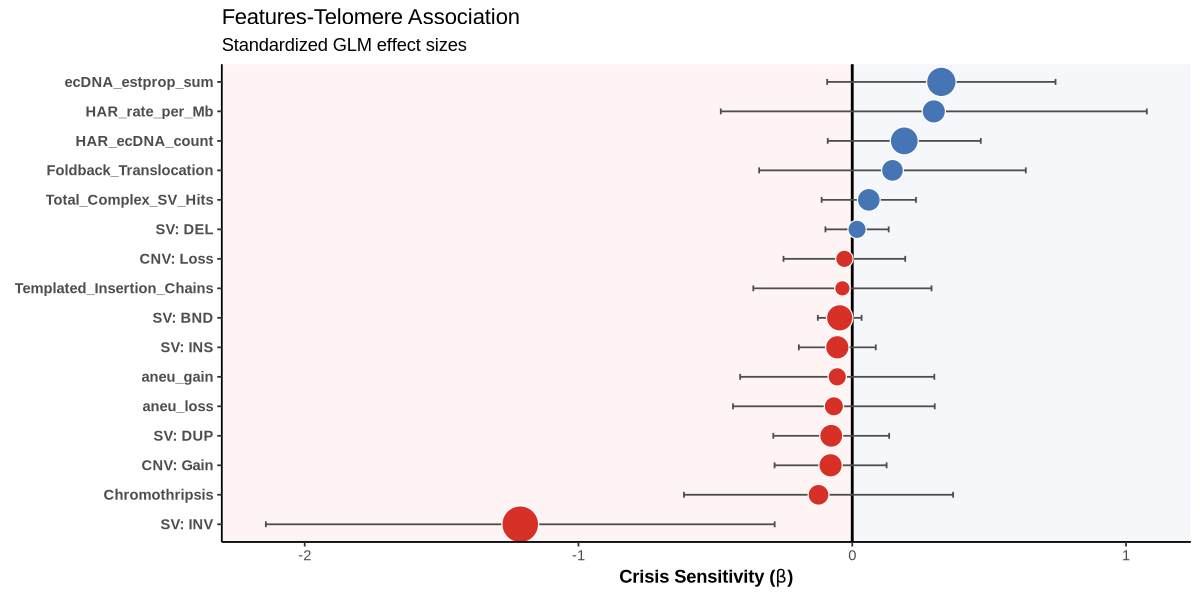

In [152]:
# --- 3. DATA CLEANING & RANKING ---
plot_data_all <- glm_all_results %>%
  mutate(
    # Human-readable labels
    Label = Variable %>% 
      gsub("sv_rate_", "SV: ", .) %>% 
      gsub("cnv_rate_per_mb_", "CNV: ", .) %>%
      gsub("_log", "", .),
    Lower = Estimate - (1.96 * StdErr),
    Upper = Estimate + (1.96 * StdErr),
    # Sort by Estimate magnitude
    Label = factor(Label, levels = Label[order(Estimate)])
  )

# --- 4. THE ALL-VARIABLE FOREST PLOT ---
ggplot(plot_data_all, aes(x = Estimate, y = Label)) +
  # Visual Zones
  annotate("rect", xmin = -Inf, xmax = 0, ymin = -Inf, ymax = Inf, fill = "#d73027", alpha = 0.05) +
  annotate("rect", xmin = 0, xmax = Inf, ymin = -Inf, ymax = Inf, fill = "#4575b4", alpha = 0.05) +
  
  geom_vline(xintercept = 0, color = "black", size = 0.8) +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.2, color = "grey30") +
  geom_point(aes(fill = Estimate < 0, size = -log10(Pval)), shape = 21, color = "white") +
  
  scale_fill_manual(values = c("TRUE" = "#d73027", "FALSE" = "#4575b4")) +
  scale_size_continuous(range = c(4, 10)) +
  
  labs(
    title = "Features-Telomere Association",
    subtitle = "Standardized GLM effect sizes",
    x = expression(bold("Crisis Sensitivity (") * beta * bold(")")), y = NULL
  ) +
  theme_classic() +
  theme(axis.text.y = element_text(face = "bold"), legend.position = "none")